# Image exploration

- np: H, W, C
- torch: C, H, W
  
- To PyTorch: `torch.from_numpy(np_arr).permute(2, 0, 1)`
- To NumPy: `torch_tensor.permute(1, 2, 0).numpy()`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
from skimage.data import camera, coffee, astronaut

In [3]:
img = camera()
type(img)
img.shape  # H, W (no channel dim.)

numpy.ndarray

(512, 512)

In [4]:
img.min()
img.max()

np.uint8(0)

np.uint8(255)

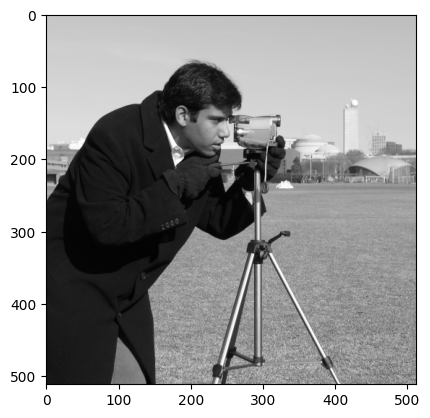

In [5]:
_ = plt.imshow(img, cmap='gray')
# _ = plt.axis('off')

In [6]:
img = coffee()
img.shape  # H, W, C

(400, 600, 3)

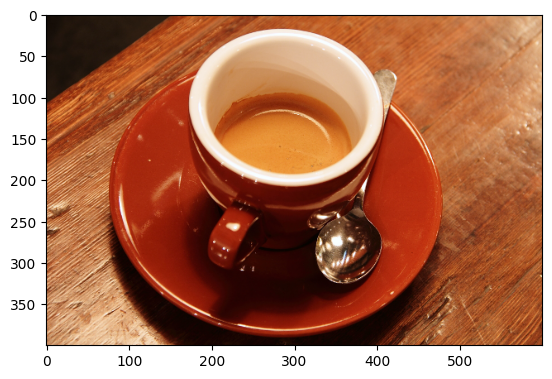

In [7]:
_ = plt.imshow(img)

## Extract individual channel values

In [8]:
red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]

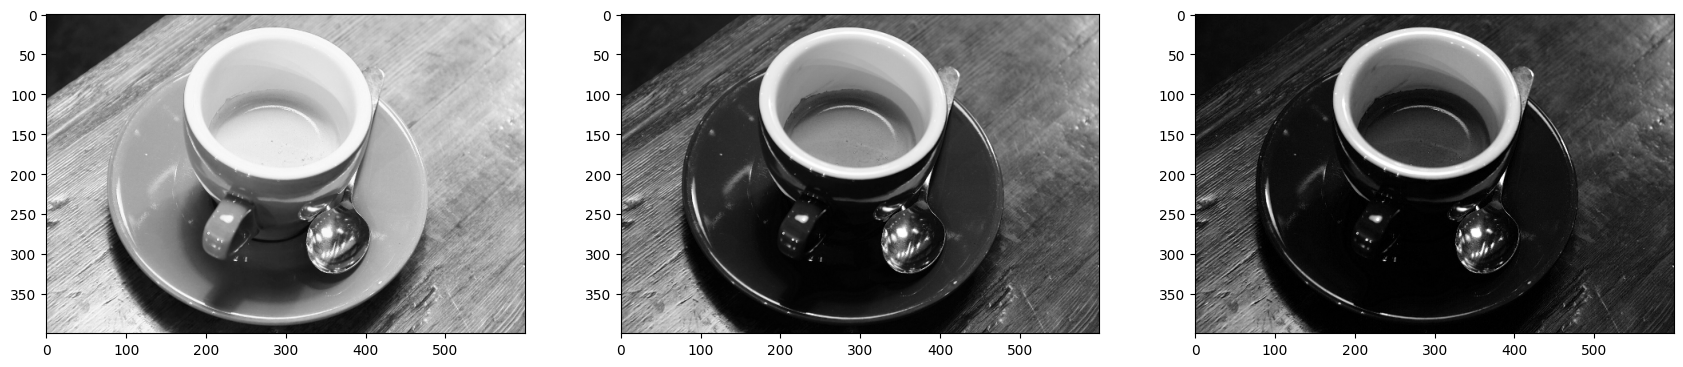

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

_ = axes[0].imshow(red, cmap='gray')
_ = axes[1].imshow(green, cmap='gray')
_ = axes[2].imshow(blue, cmap='gray')

In [10]:
red.mean()
green.mean()
blue.mean()

np.float64(158.5690875)

np.float64(85.794025)

np.float64(51.48475)

np.float64(0.0)

np.float64(1.0)

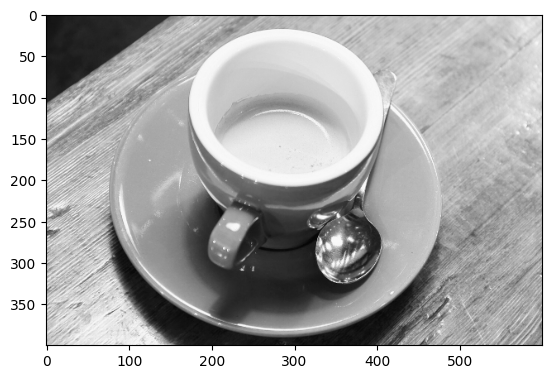

In [11]:
red_normalized = red / 255
red_normalized.min()
red_normalized.max()
_ = plt.imshow(red_normalized, cmap='gray')

# Cropping

In [12]:
img = astronaut()
img.shape

(512, 512, 3)

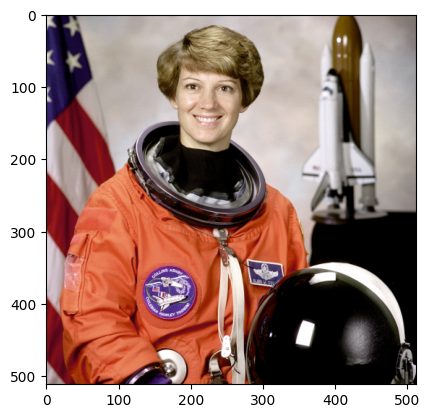

In [13]:
_ = plt.imshow(img)

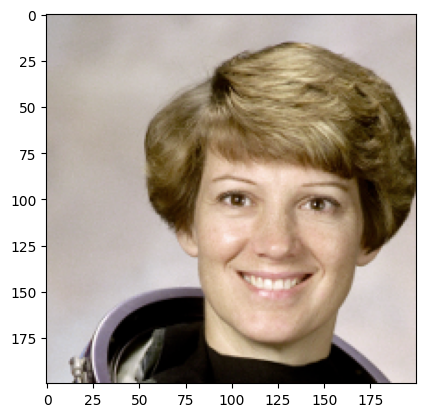

In [14]:
_ = plt.imshow(img[:200, 100:300])

# Understanding 3D arrays

In [15]:
arr = np.array([
    [15, 16, 17, 18],  # row 0
    [44, 45, 46, 47],  # row 1
    [90, 91, 92, 93],  # row 2
])

arr.shape

(3, 4)

In [16]:
# arr is "a" grid of 3 rows & 4 cols, each cell has 2 nums
# arr shape is (3, 4, 2) ~ (H, W, C)
arr_hwc = np.array([
    [[15, 100], [16, 140], [17, 170], [18, 110]],  # row 0
    [[44, 230], [45, 100], [46, 100], [47, 210]],  # row 1
    [[90, 500], [91, 200], [92, 280], [93, 830]],  # row 2
])

arr_hwc.shape

(3, 4, 2)

In [17]:
# arr contains 2 grids, each grid is 3x4
# arr shape is (2, 3, 4) ~ (C, H, W)
arr_chw = np.array([
    [
        [15, 16, 17, 18],  # row 0
        [44, 45, 46, 47],  # row 1
        [90, 91, 92, 93],  # row 2
    ],
    [
        [100, 140, 170, 110],  # row 0
        [230, 100, 100, 210],  # row 1
        [500, 200, 280, 830],  # row 2
    ]
])

arr_chw.shape

(2, 3, 4)

In [18]:
# arr_hwc -> arr_chw

arr_hwc.shape
c1 = arr_hwc[:, :, 0]
c2 = arr_hwc[:, :, 1]
arr_new = np.array([c1, c2])
arr_new.shape

(3, 4, 2)

(2, 3, 4)

## np (H, W, C) <-> torch (C, H, W)

In [19]:
img.shape  # H, W, C

img_new = np.array([img[:, :, 0],
                    img[:, :, 1],
                    img[:, :, 2],])
img_new.shape  # C, H, W

(512, 512, 3)

(3, 512, 512)

In [20]:
img_tensor = torch.from_numpy(img).permute(2, 0, 1)
img.shape  # H(0), W(1), C(2)
img_tensor.shape  # C(2), H(0), W(1)

(512, 512, 3)

torch.Size([3, 512, 512])

In [21]:
img_np = img_tensor.permute(1, 2, 0).numpy()
img_tensor.shape  # C(0), H(1), W(2)
img_np.shape  # H(1), W(2), C(0)

torch.Size([3, 512, 512])

(512, 512, 3)

# MNIST

In [22]:
from torchvision.datasets import MNIST

In [23]:
train_dataset = MNIST(root='./data', train=True, download=True)
test_dataset = MNIST(root='./data', train=False, download=True)

In [24]:
len(train_dataset)
len(test_dataset)

60000

10000

In [25]:
img, label = train_dataset[0]  # PIL.Image, int
img
label

5

(28, 28)

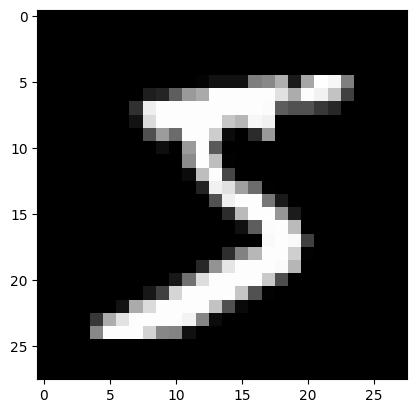

In [26]:
img.size
_ = plt.imshow(img, cmap='gray')

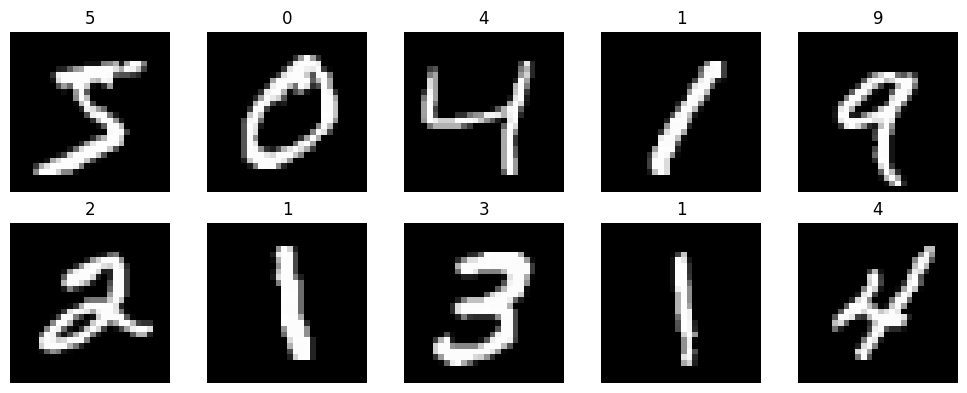

In [27]:
# show first 10 images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for i in range(10):
  img, label = train_dataset[i]
  _ = axes[i].imshow(img, cmap='gray')
  _ = axes[i].set_title(label)
  _ = axes[i].axis('off')

plt.tight_layout()

## MNIST (but with transform)

In [29]:
from torchvision.transforms import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [30]:
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

In [32]:
img, label = train_dataset[0]  # torch.Tensor, int
img.shape
label

torch.Size([1, 28, 28])

5

In [43]:
img.shape
img[0].shape

torch.Size([1, 28, 28])

torch.Size([28, 28])

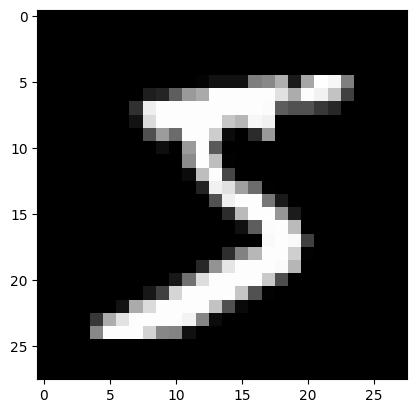

In [53]:
# plt.imshow(HxW) # works for both arrays & tensors
# plt.imshow(HxWxC) # works for both arrays & tensors

# _ = plt.imshow(img[0], cmap='gray')
_ = plt.imshow(img.permute(1, 2, 0), cmap='gray')

In [42]:
fruits = np.array([
    [['apple', 10], ['banana', 15], ['kiwi', 5]],  # 3x2
    [['orange', 25], ['mango', 20], ['grapes', 35]],  # 3x2
])  # 2x3x2

fruits.shape
fruits[0].shape
fruits[0][0].shape
fruits[0][0][0].shape

(2, 3, 2)

(3, 2)

(2,)

()